In [42]:
# Standard libraries
import time
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [43]:
# Load the dataset from CSV
df = pd.read_csv("bodyPerformance.csv")

# Display first 5 rows
# Placed in a separate cell so the table renders correctly in Jupyter
display(df.head())

# Verify shape and inspect column types and non-null counts
print("Shape:", df.shape)
df.info()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


Shape: (13393, 12)
<class 'pandas.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  str    
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  str    
dtypes: float64(10), str(2)
memory usage: 1.2 MB


In [44]:
# --- Feature encoding ---
# 'gender' is the only categorical column: M -> 0, F -> 1
df['gender'] = df['gender'].map({'M': 0, 'F': 1})


# Map class labels to zero-indexed integers, as required by CrossEntropyLoss
# A -> 0  (best performance)
# B -> 1
# C -> 2
# D -> 3  (weakest performance)

df['class'] = df['class'].map({'A': 0, 'B': 1, 'C': 2, 'D': 3})  #givimg the integers as crossentryloops need it 
# --- Separate features and target ---
X = df.drop('class', axis=1).values
y = df['class'].values

# Derive constants from the data -> referenced consistently throughout the notebook
n_features  = X.shape[1]        # 11
num_classes = len(np.unique(y)) # 4

print("Feature matrix shape:", X.shape)
print("Target shape:",         y.shape)
print(f"n_features = {n_features},  num_classes = {num_classes}")
print("Class distribution:", pd.Series(y).value_counts().sort_index().to_dict())

Feature matrix shape: (13393, 11)
Target shape: (13393,)
n_features = 11,  num_classes = 4
Class distribution: {0: 3348, 1: 3347, 2: 3349, 3: 3349}


In [45]:
# Split into training (80%) and test (20%) sets
# stratify=y ensures proportional class representation in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardise features: fit ONLY on training data to prevent data leakage
# This computes mean and standard deviation from the training set only
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Training set:", X_train.shape, "| Test set:", X_test.shape)

Training set: (10714, 11) | Test set: (2679, 11)


In [46]:
# Convert feature arrays to float32 tensors -> required by all neural network layers
X_train_mlp = torch.tensor(X_train, dtype=torch.float32)
X_test_mlp  = torch.tensor(X_test,  dtype=torch.float32)

# Labels must be dtype=torch.long (int64) for CrossEntropyLoss
# Shape is (N,) -> do NOT add .view(-1, 1) as in the binary version
y_train_tensor = torch.tensor(y_train, dtype=torch.long) #training labels as PyTorch integer tensors.
print("X_train_mlp shape:   ", X_train_mlp.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("Label dtype:         ", y_train_tensor.dtype)

X_train_mlp shape:    torch.Size([10714, 11])
y_train_tensor shape: torch.Size([10714])
Label dtype:          torch.int64


In [59]:
# Reshape to (samples, n_features, 1) for sequence models
# n_features=11 time steps, each with 1 input feature
X_train_seq = X_train_mlp.unsqueeze(2)  # Adds a new dimension at index 2
X_test_seq  = X_test_mlp.unsqueeze(2)
print("Sequence training shape:", X_train_seq.shape)


# --- DataLoaders ---
batch_size = 32

# MLP DataLoader: flat input of shape (batch, n_features)
mlp_train_loader = DataLoader(
    TensorDataset(X_train_mlp, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

# Sequence DataLoader: reshaped input of shape (batch, n_features, 1)
seq_train_loader = DataLoader(
    TensorDataset(X_train_seq, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

Sequence training shape: torch.Size([10714, 11, 1])


In [48]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            # Input layer: n_features inputs -> 64 hidden units
            nn.Linear(n_features, 64),  #11 input features to 64 neurons 
            nn.ReLU(),
            # Dropout regularisation: randomly deactivates 30% of neurons during training
            nn.Dropout(0.3),

            # Hidden layer: 64 -> 32 neurons
            nn.Linear(64, 32),
            nn.ReLU(),

            # Output layer: one logit per class
            # No activation here -> **CrossEntropyLoss applies log-softmax internally**
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [60]:
class RNNModel(nn.Module):

    def __init__(self):
        super().__init__()

        # input_size=1: each of the 11 time steps carries a single feature
        # hidden_size=32: dimensionality of the hidden state representation
        # batch_first=True: input shape is (batch, sequence_length, features)
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        # Maps the final hidden state to one logit per class
        self.fc = nn.Linear(32, num_classes)
    def forward(self, x):
        # hidden shape: (num_layers, batch, hidden_size)
        _, hidden = self.rnn(x)
        # hidden[-1]: last layer, shape (batch, hidden_size)
        return self.fc(hidden[-1])

In [62]:
class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        # LSTM: captures long-range dependencies via gated memory cell
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )
        
        self.fc =nn.Linear(32,num_classes)

    def forward(self, x):
        # LSTM returns (output, (hidden, cell))
        # We only need the final hidden state
        _, (hidden, _) = self.lstm(x)
        # hidden[-1]: last layer hidden state, shape (batch, hidden_size)
        return self.fc(hidden[-1])

In [64]:
class GRUModel(nn.Module):

    def __init__(self):
        super().__init__()

        # GRU: simplified variant of LSTM using update and reset gates
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        self.fc = nn.Linear(32, num_classes) #34 units to 4 classes. a,b,c,d  

    def forward(self, x):
        # GRU returns (output, hidden)
        _, hidden = self.gru(x)
        # hidden[-1]: last layer hidden state, shape (batch, hidden_size)
        return self.fc(hidden[-1])

In [65]:
def train_model(model, loader, epochs=50):

    # Move model to device BEFORE creating the optimiser
    # Best practice: parameters must be on the target device before the optimiser registers them
    model.to(device)

    # CrossEntropyLoss for multiclass classification
    # Input:  logits of shape (N, num_classes)
    # Target: integers of shape (N,) with dtype=torch.long
    criterion = nn.CrossEntropyLoss()
    # criterion = ??

    # Adam optimiser with a commonly used default learning rate
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    losses = []
    start_time = time.time()

    for epoch in range(epochs):

        # Activate training mode: enables dropout and gradient computation
        model.train()
        epoch_loss = 0

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)              # shape: (batch, num_classes)
            loss    = criterion(outputs, y_batch)  # y_batch shape: (batch,)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        losses.append(epoch_loss / len(loader))

    training_time = time.time() - start_time
    return losses, training_time

In [66]:
def evaluate_model(model, X_test, y_test):
 
    # Disable dropout and batch normalisation for evaluation
    model.eval()
 
    with torch.no_grad():
        # Compute raw logits and move to CPU for numpy conversion
        logits = model(X_test.to(device)).cpu()
 
    # Predicted class: index of the highest logit per sample
    # Shape: (N,) -> directly comparable to y_test
    predictions = torch.argmax(logits, dim=1).numpy()
 
    # Per-class probabilities: softmax normalises logits to a valid probability distribution
    # Shape: (N, num_classes) -> required format for multiclass roc_auc_score
   
    probabilities = torch.softmax(logits, dim=1).numpy()
 
    return {
        "Accuracy":  accuracy_score(y_test, predictions),
        # average='weighted': each class contributes proportionally to its frequency in y_test
        "Precision": precision_score(y_test, predictions, average='weighted', zero_division=0),
        "Recall":    recall_score(y_test, predictions, average='weighted', zero_division=0),
        "F1":        f1_score(y_test, predictions, average='weighted', zero_division=0),
        # multi_class='ovr': one-vs-rest -> each class is compared against all remaining classes
        # probabilities shape (N, num_classes) is the required format for this setting
        "ROC_AUC":   roc_auc_score(y_test, probabilities, multi_class='ovr', average='weighted')
    }

In [67]:
def plot_confusion_matrix(model, X_eval, y_test, name):
 
    model.eval()
 
    with torch.no_grad():
        logits = model(X_eval.to(device)).cpu()
 
    # Argmax gives the predicted class index for each sample
    predictions = torch.argmax(logits, dim=1).numpy()
 
    fig, ax = plt.subplots(figsize=(5, 4))
 
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels= ['A', 'B', 'C', 'D'],
        colorbar=False,  # keeps the plot clean without a colour scale bar
        ax=ax
    )
 
    ax.set_title(f"{name}: Confusion Matrix")
    plt.tight_layout()
    plt.show()
 

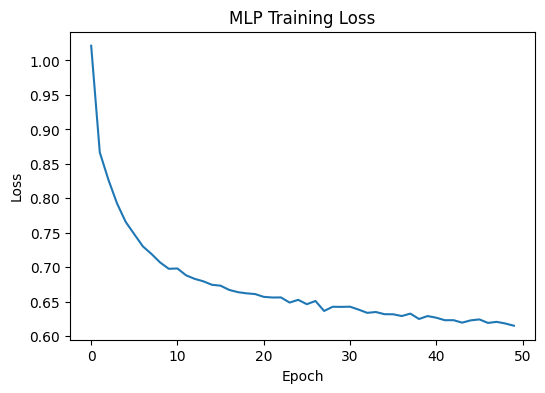

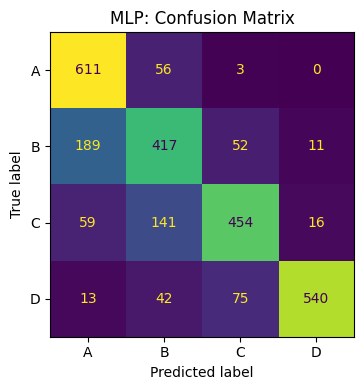

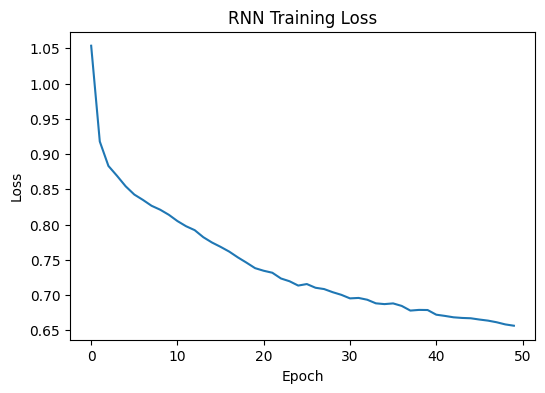

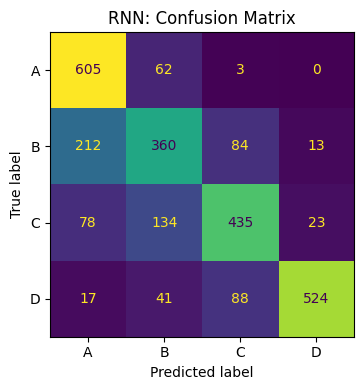

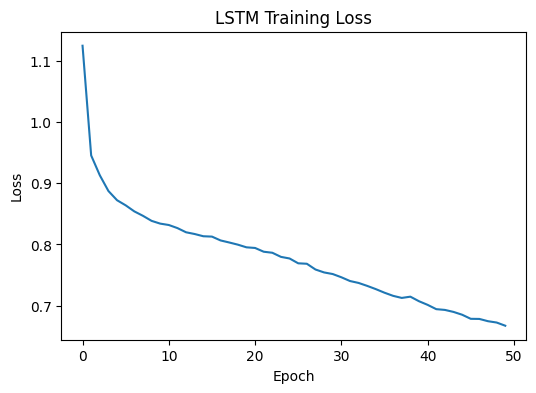

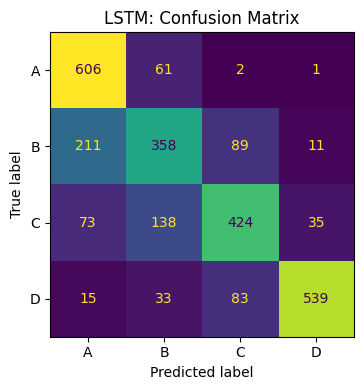

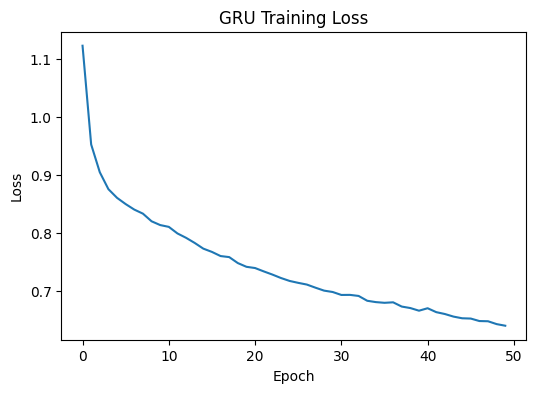

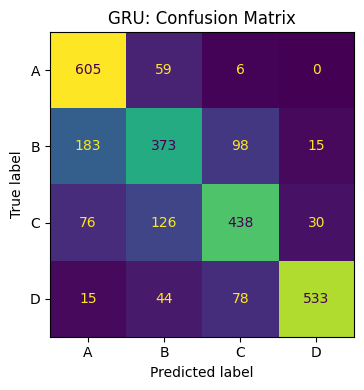

In [68]:
results = []
 
models = {
    "MLP":  (MLP(),       mlp_train_loader, X_test_mlp),
    "RNN":  (RNNModel(),  seq_train_loader, X_test_seq),
    "LSTM": (LSTMModel(), seq_train_loader, X_test_seq),
    "GRU":  (GRUModel(),  seq_train_loader, X_test_seq)
}
 
for name, (model, loader, X_eval) in models.items():
 
    # Train the model and record training time
    # Make sure the training function is available in this cell
    if 'train_model' not in globals():
        def train_model(model, loader, epochs=100):
            model.to(device)
 
            criterion = nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(model.parameters(), lr=2)
 
            losses = []
            start_time = time.time()
 
            for epoch in range(epochs):
                model.train()
                epoch_loss = 0.0
 
                for X_batch, y_batch in loader:
                    X_batch = X_batch.to(device)
                    y_batch = y_batch.to(device)
 
                    optimizer.zero_grad()
                    outputs = model(X_batch)
                    loss = criterion(outputs, y_batch)
 
                    loss.backward()
                    optimizer.step()
 
                    epoch_loss += loss.item()
 
                losses.append(epoch_loss / len(loader))
 
            return losses, time.time() - start_time
 
    losses, train_time = train_model(model, loader)
 
    # Evaluate on the test set
    metrics = evaluate_model(model, X_eval, y_test)
 
    metrics["Model"] = name
    metrics["Training Time (s)"] = round(train_time, 2)
    results.append(metrics)
 
    # Training loss curve
    plt.figure(figsize=(6, 4))
    plt.plot(losses)
    plt.title(f"{name} Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()
 
    # Per-class confusion matrix for this model
    plot_confusion_matrix(model, X_eval, y_test, name)
 

In [69]:
results_df = pd.DataFrame(results)

results_df = results_df[[
    "Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "Training Time (s)"
]]

# Sort by weighted F1 -> more informative than Accuracy alone for multiclass problems
results_df.sort_values(by="F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training Time (s)
0,MLP,0.754759,0.766583,0.754759,0.754815,0.926292,4.46
3,GRU,0.727510,0.734163,0.727510,0.725383,0.913384,15.47
1,RNN,0.718178,0.728852,0.718178,0.716379,0.905092,8.52
2,LSTM,0.719298,0.726349,0.719298,0.716375,0.906680,17.39
